<a href="https://colab.research.google.com/github/SofiaKakou/Customer_Churn_Prediction/blob/main/notebooks/06_shap_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Introduction

This notebook focuses on interpreting the machine learning model using SHAP (SHapley Additive exPlanations)

Purpose:
- Understand how features influence model predictions
- identify key drivers of customer churn
- explain both global and individual predictions

This is important for translatng machine learning results into actionable business insights.


# 2.Imports


In [ ]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# 3.Load Dataset & Model

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the prepared datasets
base_path = "/content/drive/MyDrive/Thesis/Prepared Data/"

x_train = pd.read_csv(base_path + "x_train.csv")
x_test = pd.read_csv(base_path + "x_test.csv")
y_train = pd.read_csv(base_path + "y_train.csv").squeeze()
y_test = pd.read_csv(base_path + "y_test.csv").squeeze()

In [ ]:
# Load / Retrain XGBoost Model

model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# 4.SHAP Setup

In [ ]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP Values
shap_values = explainer.shap_values(x_test)

# 5.Global SHAP Analysis

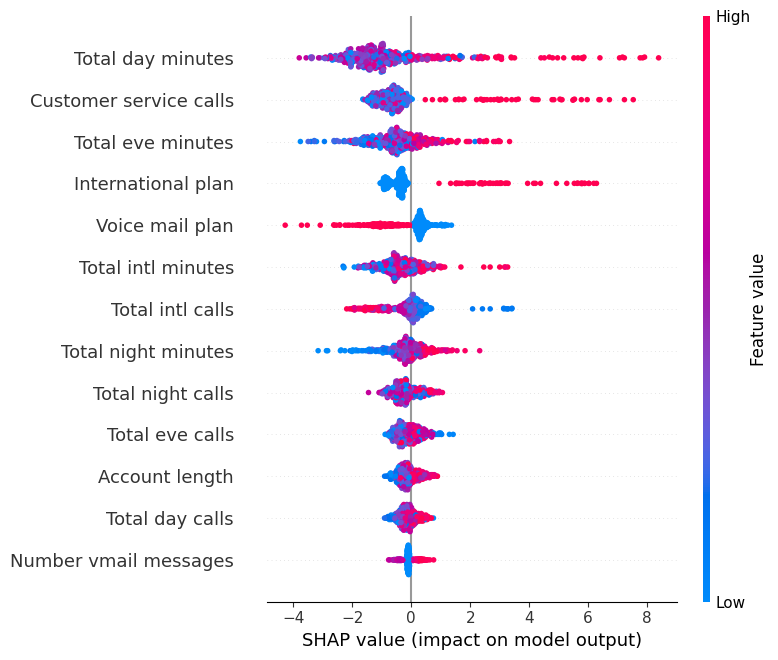

In [ ]:
shap.summary_plot(shap_values, x_test)

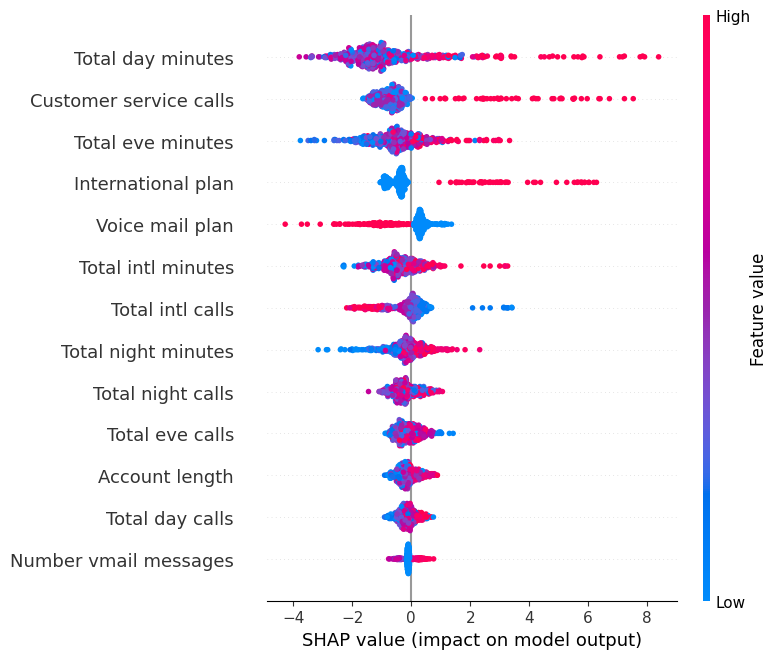

In [ ]:
# saving the plot visuals for the dashboard
shap.summary_plot(shap_values, x_test, show=False)
plt.tight_layout()
plt.savefig(base_path + 'shap_summary.png', bbox_inches="tight", dpi=300)
plt.show()

## Observations

The SHAP summary plot shows the overall impact of each feature on model predictions.
Features at the top have the strongest influence on churn prediction.
Color indicates feature value (red = high, blue = low)
Features with wider spread have greater impact

This provides global understanding of which variables drive churn.

# 6.Bar Plot

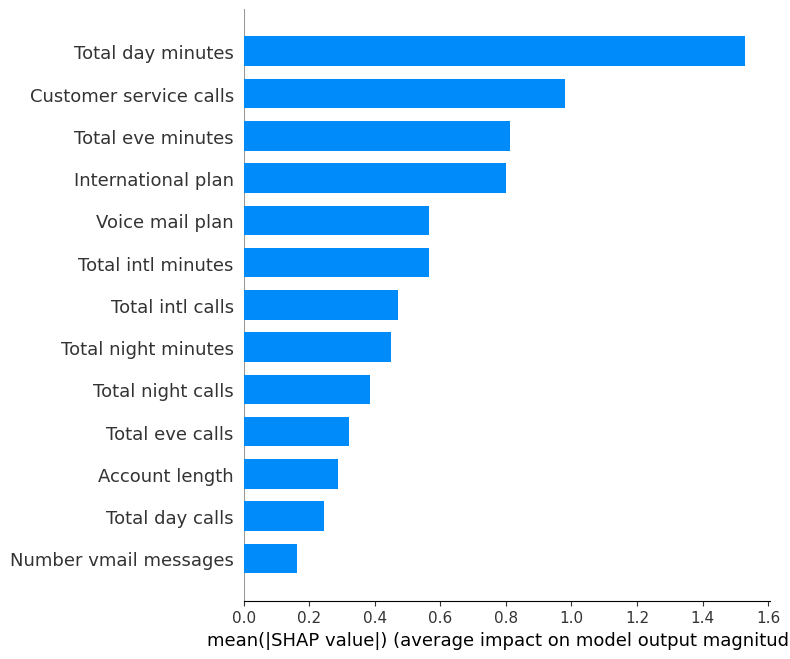

In [ ]:
shap.summary_plot(shap_values, x_test, plot_type="bar")

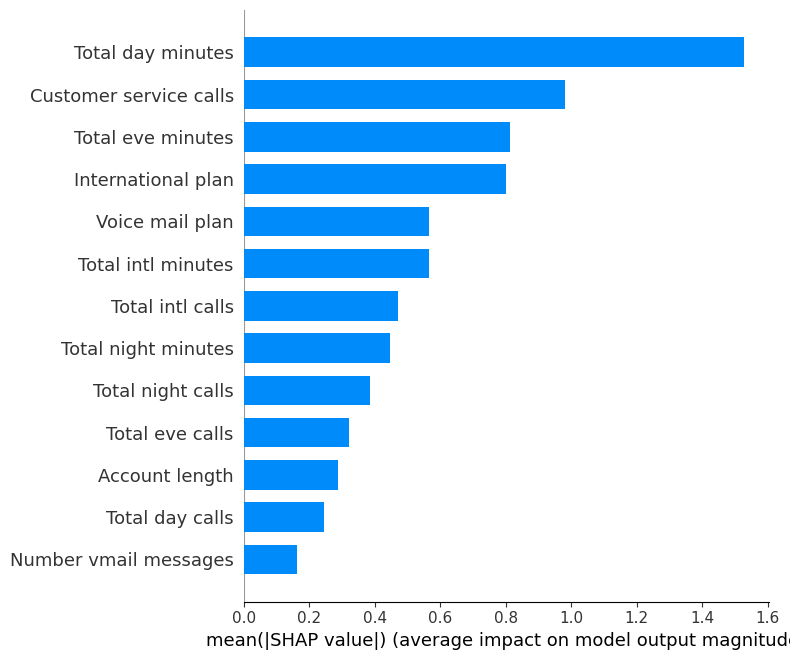

In [ ]:
# saving plot visuals for the dashboard
shap.summary_plot(shap_values, x_test, plot_type="bar", show=False)

plt.tight_layout()
plt.savefig(base_path + 'shap_bar.png', bbox_inches="tight", dpi=300)
plt.show()

  ## Comments

  The bar plot provides a simplified ranking of feature importance based on SHAP values.
  This helps identify the most influential predictors in a clear and interpretable way.

# 7.Local SHAP Analysis

In [ ]:
# One example
shap.initjs()
index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    x_test.iloc[index]
    )

## Comments

The force plot explains how individual features contribute to a single prediction.

- Features pushing towards churn are shown in one direction
- Features pushing against churn are shown in the opposite direction.

This Helps understand why the model made a specific decision.

## Key Insights

Based on SHAP Insights

- Usage related features are strong drivers of churn
- Customer service interactions significantly influence predictions
- Certain features consistently increase the likelihood of churn when their values are high

These findings align with earlier EDA results and confirm the importance of behavioral patterns in customer churn.

# 8.Business Interpretation

The model insights suggest that:
- Customers with high usage patterns may be more likely to churn
-  Frequent customer service interactions may indicate dissatisfaction
- Monitoring these factors can help identify at rist customers early

These insights can be used by businesses to design retention strategies and improve customer satisfaction.

# 9.Dashboard Preparation

In [28]:
# save sample set for dashboard
x_test.head(100).to_csv(base_path + "dashboard_sample.csv", index=False)

# save feature importance tables
rf_importance = pd.read_csv(base_path + "rf_importance.csv")
xgb_importance = pd.read_csv(base_path + "xgb_importance.csv")

# save model comparison results
results_df = pd.read_csv(base_path + "model_results.csv")

print("Dashboard Files prepared successfully.")

Dashboard Files prepared successfully.
